# Aging mouse brain: inference from the formal 19-age fixed-seed alignment

This tutorial applies the current public `spalignde` inference API to the five-section Figure 5A subset of the formal aging-brain alignment. The complete upstream archive contains 19 fixed-seed query-age alignments to the unchanged 4.3-month reference, produced with Leiden resolution `0.8`, alignment seed `1000`, and 800 S-LDDMM iterations. The website example consumes four of those formal query files—6.6, 15.8, 30.9, and 34.5 months—plus the unchanged 4.3-month reference. It uses their saved `x_aligned` and `y_aligned` coordinates and does not rerun alignment.

`Gamt` and `Vip` are fitted so the notebook can demonstrate both the reported global linear age-trend test and automatic trajectory-cluster selection; the local-statistic map remains focused on `Gamt`. The original 300-gene MERFISH data were published by Sun et al. and are available from [Zenodo record 13883177](https://doi.org/10.5281/zenodo.13883177). Raw counts are normalized to a library size of 250. The density channel receives 25% of standardized mismatch-feature energy; the gene-specific condition offset and local technical covariates are included. Mismatch-aware variance adjustment and connected-region cleanup are enabled, cell-type adjustment is disabled, and grid-level significance uses $q \leq 0.05$.

**Fixed-seed reproducibility.** Upstream alignment uses seed `1000`; preparation, fitting, and trajectory clustering use seed `1` and `n_jobs=1`. Set `PYTHONHASHSEED=1` before kernel startup and retain the documented input order and numerical-library environment. Repeated runs reproduce the reported summaries; floating-point calibration values can differ in the last displayed digits.

In [1]:
from pathlib import Path
import json
import os
import random

import numpy as np
import pandas as pd
from IPython.display import display

import spalignde
from spalignde import (
    cluster_trajectories,
    fit_local_de,
    gene_level_acat_pvalue,
    gene_level_age_trend_acat,
    plot_local_result,
    prepare_inference,
)
from spalignde.datasets import (
    AGING_BRAIN_FIGURE5A_REFERENCE,
    AGING_BRAIN_FIGURE5A_SAMPLES,
    aging_brain_figure5a_genes,
    load_aging_brain_figure5a,
)

WORKFLOW_SEED = 1
random.seed(WORKFLOW_SEED)
np.random.seed(WORKFLOW_SEED)

print("spalignde version:", spalignde.__version__)

spalignde version: 0.1.0


## Load counts and the formal fixed-seed coordinates

All 300 expression columns are retained because mismatch-risk estimation screens a broad stable-gene candidate panel even though only `Gamt` and `Vip` are fitted below. The expression loader supplies raw counts and annotations. The code then replaces only `x_aligned` and `y_aligned` from the repository's hash-tracked coordinate handoff generated from the formal 19-query archive. Cell IDs are matched explicitly; row order is never used.

The website subset uses four of the 19 formal query outputs. The 4.3-month reference retains its coordinates from the corresponding fixed-seed `run_1/cluster_labels.csv.gz`. Set `SPALIGNDE_AGING_COORDINATE_DIR` only when validating an equivalent packaged coordinate directory.

In [2]:
def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "src/spalignde/datasets/aging_brain").is_dir():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from a spAlignDE checkout containing "
        "src/spalignde/datasets/aging_brain."
    )


REPOSITORY_ROOT = find_repository_root()
FORMAL_COORDINATE_DIR = Path(
    os.environ.get(
        "SPALIGNDE_AGING_COORDINATE_DIR",
        REPOSITORY_ROOT / "src/spalignde/datasets/aging_brain",
    )
).expanduser().resolve()

risk_genes = list(aging_brain_figure5a_genes())
data = load_aging_brain_figure5a()
metadata = json.loads(
    (FORMAL_COORDINATE_DIR / "metadata.json").read_text(encoding="utf-8")
)

for sample_id in AGING_BRAIN_FIGURE5A_SAMPLES:
    stem = sample_id.replace(".", "_")
    coordinate_path = FORMAL_COORDINATE_DIR / f"{stem}_observations.csv.gz"
    coordinates = pd.read_csv(
        coordinate_path,
        usecols=["cell_id", "x_aligned", "y_aligned"],
    )
    if coordinates["cell_id"].astype(str).duplicated().any():
        raise ValueError(f"Duplicate coordinate cell IDs in {coordinate_path.name}.")
    selected = data["sample_id"].astype(str).eq(sample_id)
    ordered_ids = data.loc[selected, "cell_id"].astype(str)
    matched = coordinates.set_index(coordinates["cell_id"].astype(str)).reindex(
        ordered_ids
    )
    if matched[["x_aligned", "y_aligned"]].isna().any().any():
        raise ValueError(f"{sample_id} contains cells without formal coordinates.")
    data.loc[selected, ["x_aligned", "y_aligned"]] = matched[
        ["x_aligned", "y_aligned"]
    ].to_numpy(dtype=float)

print(f"Samples: {AGING_BRAIN_FIGURE5A_SAMPLES}")
print(f"Cells: {len(data):,}; risk-gene candidates: {len(risk_genes)}")
print("Formal upstream query alignments:", metadata["alignment"]["formal_query_count"])
print("Website query subset:", metadata["queries"])
print("Aligned-coordinate source:", metadata["coordinate_system"])
data.groupby("sample_id", sort=False).size().rename("n_cells").to_frame()

Samples: ('age_4.3', 'age_6.6', 'age_15.8', 'age_30.9', 'age_34.5')
Cells: 371,330; risk-gene candidates: 300
Formal upstream query alignments: 19
Website query subset: ['age_6.6', 'age_15.8', 'age_30.9', 'age_34.5']
Aligned-coordinate source: formal fixed-seed resolution-0.8, 800-iteration spAlignDE coordinates


,n_cells
sample_id,
age_4.3,79824
age_6.6,78862
age_15.8,72453
age_30.9,66416
age_34.5,73775


## Construct the shared grid and mismatch-risk maps

The packaged aligned coordinates define the common inference space. With `grid_n=None`, the package applies its data-driven shared-grid rule. Both tested genes are prepared on the same grid and risk maps.

In [3]:
GENES = ["Gamt", "Vip"]

prepared = prepare_inference(
    data,
    reference=AGING_BRAIN_FIGURE5A_REFERENCE,
    genes=GENES,
    risk_genes=risk_genes,
    density_energy_share=0.25,
    library_size=250,
    grid_n=None,
    n_jobs=1,
    random_state=WORKFLOW_SEED,
)

{
    "grid_n": prepared.metadata["grid_n"],
    "shared_grid_locations": prepared.metadata["shared_grid_locations"],
    "grid_selection": prepared.metadata["grid_n_source"],
}

[INFO] detecting tissue geometry on 371330 spots ...


[INFO] geometry ready: 5 holes, 75868 grid points, R=119.7, h_grid=26.65, R_map=39.97


[INFO] building KNN trees for 5 samples ...


[SWND] N_A=79824, N_B=78862, G=300


[marker-screen] var_thr=0.0173592 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=228 | n_cor=181 | n_all=72


...

[SWND] N_A=79824, N_B=66416, G=300


[marker-screen] var_thr=0.022063 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=187 | n_cor=139 | n_all=45


[SWND] N_A=79824, N_B=73775, G=300


[marker-screen] var_thr=0.0199347 | delta_thr=0.05 | cor_min=0.2 | n_var=150 | n_delta=188 | n_cor=153 | n_all=51


{'grid_n': 313, 'shared_grid_locations': 75868, 'grid_selection': 'r_driven'}

## Fit all four age-versus-reference contrasts

`fit_local_de` performs the complete within-contrast calibration independently for each contrast, applies the public validity checks, and combines all valid provisional coefficients by an equal-weight Huber center. The resulting single `lambda_g` is shared across that gene's four contrasts; provisional coefficients are diagnostics, not the final applied coefficients. A successful zero is valid evidence, whereas a failed calibration is excluded from aggregation. `region_cleanup=True` changes only the reported connected-region mask, not local statistics, P values, or q-values.

In [4]:
result = fit_local_de(
    prepared,
    genes=GENES,
    contrast="vs_reference",
    alpha=0.05,
    mismatch_aware=True,
    technical_adjustment=True,
    cell_type_adjustment=False,
    global_offset=True,
    region_cleanup=True,
    n_jobs=1,
    random_state=WORKFLOW_SEED,
)

calibration_rows = []
for gene in GENES:
    terrain = result.fits[gene]["terrain_data"]
    assert "Wv_by_time" in terrain and "use_by_time" in terrain
    calibration = terrain["risk_calibration"]
    assert (
        calibration["method"]
        == "per_contrast_local_calibration_then_equal_weight_huber"
    )
    calibration_rows.append(
        {
            "gene": gene,
            "total contrasts": calibration["n_contrasts_total"],
            "valid contrasts": calibration["n_contrasts_valid"],
            "valid time IDs": calibration["valid_time_ids"],
            "invalid time IDs": calibration["invalid_time_ids"],
            "lambda_g": calibration["lambda_local_hat"],
        }
    )
    provisional_summary = {
        str(time_id): {
            "valid": detail["valid"],
            "validity_reasons": detail["validity_reasons"],
            "lambda_local_hat": detail["lambda_local_hat"],
        }
        for time_id, detail in calibration["provisional_by_time"].items()
    }
    print(gene, "provisional coefficients:", provisional_summary)
    print(
        gene,
        "aggregation:",
        {
            key: calibration["aggregation"][key]
            for key in (
                "method",
                "n_valid",
                "valid_time_ids",
                "invalid_time_ids",
                "lambda_local_hat",
            )
        },
    )

display(pd.DataFrame(calibration_rows))

[risk-calib-aggregate] valid=4/4 method=Huber(kappa=1.345) lambda_local=1.15097


[risk-calib-aggregate] valid=4/4 method=Huber(kappa=1.345) lambda_local=1.15013


[batch_run] completed 2 / 2 genes
Gamt provisional coefficients: {'age_6.6': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 0.6250892148996279}, 'age_15.8': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.0384888316672125}, 'age_30.9': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 2.61887291225354}, 'age_34.5': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.208068894881113}}
Gamt aggregation: {'method': 'equal_weight_huber_location', 'n_valid': 4, 'valid_time_ids': ('age_6.6', 'age_15.8', 'age_30.9', 'age_34.5'), 'invalid_time_ids': (), 'lambda_local_hat': 1.1509686523013243}
Vip provisional coefficients: {'age_6.6': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 0.9993000261389513}, 'age_15.8': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.0232313778894113}, 'age_30.9': {'valid': True, 'validity_reasons': (), 'lambda_local_hat': 1.2728480062858307}, 'age_34.5': {'valid': True, 'validity_reasons': (), 

,gene,total contrasts,valid contrasts,valid time IDs,invalid time IDs,lambda_g
0,Gamt,4,4,"(age_6.6, age_15.8, age_30.9, age_34.5)",(),1.150969
1,Vip,4,4,"(age_6.6, age_15.8, age_30.9, age_34.5)",(),1.150132


## Global age-trend test and automatic trajectory clustering

`gene_level_age_trend_acat` is the reported multi-age global test. At each retained grid location it regresses the unsmoothed adjusted local expression (`muA_adj_by_time`) on the four query ages with an intercept, using mismatch-aware `Wv_by_time` as local precision. It performs a two-sided slope test and combines local slope P values across space with ACAT. The 4.3-month reference is not added as a fifth regression observation. This test precedes trajectory clustering and does not use smoothed trajectories, cluster labels, or the selected `K`. `gene_level_acat_pvalue` is retained below only as the distinct any-spatial-change diagnostic.

`cluster_trajectories(..., n_clusters="auto")` first assesses dynamic evidence by held-out complete-trajectory prediction and retains candidates within the one-SE plateau of the best gain. It scans that plateau from the largest `K` toward coarser resolutions, continuing while sub-`R_map` fragmentation decreases. If the next coarser candidate raises fragmentation, the current first fine-side local minimum is retained; if fragmentation keeps decreasing, the coarsest plateau candidate is retained. When the one-SE lower bound is not positive, the minimum candidate is returned. The notebook calls the public API directly and displays its `fine_to_coarse_scan` metadata rather than reproducing this selection rule.

In [5]:
trend_results = {}
trajectory_results = {}
gene_summary_rows = []
contrast_summary_rows = []

for gene in GENES:
    trend = gene_level_age_trend_acat(
        result,
        gene,
        time_values=None,
        alpha=0.05,
    )
    trajectory = cluster_trajectories(
        result,
        gene,
        n_clusters="auto",
        time_values=None,
        random_state=WORKFLOW_SEED,
    )
    trend_results[gene] = trend
    trajectory_results[gene] = trajectory
    selection = trajectory.metadata["selection"]
    gene_summary_rows.append(
        {
            "gene": gene,
            "age-trend spatial ACAT P value": trend["summary"][
                "gene_level_trend_acat_p"
            ],
            "any-spatial-change diagnostic P value": gene_level_acat_pvalue(
                result, gene
            ),
            "selected K": trajectory.result["K_TRAJ"],
        }
    )
    print(f"{gene} auto-K rule:", selection["rule"])
    print(f"{gene} dynamic candidates:", selection["dynamic_candidates"])
    print(f"{gene} fine-to-coarse order:", selection["fine_to_coarse_order"])
    print(f"{gene} fine-to-coarse scan:", selection["fine_to_coarse_scan"])
    print(f"{gene} fragmentation stop at K:", selection["fragmentation_stop_at_k"])
    print(f"{gene} rejected coarser K:", selection["rejected_coarser_k"])
    display(trajectory.result["auto_k"]["table"])

    terrain = result.fits[gene]["terrain_data"]
    for query_id in terrain["time_ids"]:
        statistic = np.asarray(terrain["stat_by_time"][query_id], dtype=float)
        q_value = np.asarray(terrain["q_by_time"][query_id], dtype=float)
        reported_mask = np.asarray(
            terrain["sig_mask_by_time"][query_id], dtype=bool
        )
        raw_q_mask = np.isfinite(q_value) & (q_value <= 0.05)
        contrast_summary_rows.append(
            {
                "gene": gene,
                "contrast": f"{query_id} - age_4.3",
                "q <= 0.05 grid locations": int(raw_q_mask.sum()),
                "reported grids after cleanup": int(reported_mask.sum()),
                "minimum q-value": float(np.nanmin(q_value)),
                "median |t|": float(np.nanmedian(np.abs(statistic))),
            }
        )

gene_summary = pd.DataFrame(gene_summary_rows)
contrast_summary = pd.DataFrame(contrast_summary_rows)
display(gene_summary)
display(contrast_summary)

Gamt auto-K rule: held-out complete-trajectory evidence, then fine-to-coarse first local minimum of R_map-footprint fragmentation
Gamt dynamic candidates: [3]
Gamt fine-to-coarse order: [3]
Gamt fine-to-coarse scan: []
Gamt fragmentation stop at K: 3
Gamt rejected coarser K: nan


,K,mean_dynamic_gain,se_dynamic_gain,mean_shared_time_loss,mean_cluster_specific_time_loss,R_map,R_map_footprint_grid_locations,n_connected_components,minimum_component_grid_locations,small_components_below_one_Rmap_footprint,grid_fraction_in_small_components,within_one_SE_of_best_dynamic_gain,dynamic_candidate,fine_to_coarse_rank,fine_to_coarse_visited,selected_final_k
0,2,0.479429,0.207232,368.840522,101.356155,39.967634,9,26,3,4,0.000277,False,False,NaN,False,False
1,3,0.672225,0.096069,447.924527,104.776690,39.967634,9,137,1,27,0.001674,True,True,1.0,True,True
2,4,0.355099,0.165932,511.480015,291.542361,39.967634,9,265,1,50,0.002583,False,False,NaN,False,False
3,5,0.262530,0.185869,545.952076,393.510114,39.967634,9,295,1,68,0.003453,False,False,NaN,False,False
4,6,0.227572,0.191235,583.268936,421.853745,39.967634,9,405,1,77,0.004416,False,False,NaN,False,False
5,7,0.218214,0.185892,604.401088,456.062842,39.967634,9,559,1,135,0.007065,False,False,NaN,False,False
6,8,0.189129,0.193354,619.136948,481.326924,39.967634,9,691,1,162,0.007908,False,False,NaN,False,False
7,9,0.187859,0.191492,631.718921,505.009718,39.967634,9,843,1,212,0.010993,False,False,NaN,False,False


Vip auto-K rule: held-out complete-trajectory evidence, then fine-to-coarse first local minimum of R_map-footprint fragmentation
Vip dynamic candidates: [2]
Vip fine-to-coarse order: [2]
Vip fine-to-coarse scan: []
Vip fragmentation stop at K: nan
Vip rejected coarser K: nan


,K,mean_dynamic_gain,se_dynamic_gain,mean_shared_time_loss,mean_cluster_specific_time_loss,R_map,R_map_footprint_grid_locations,n_connected_components,minimum_component_grid_locations,small_components_below_one_Rmap_footprint,grid_fraction_in_small_components,within_one_SE_of_best_dynamic_gain,dynamic_candidate,fine_to_coarse_rank,fine_to_coarse_visited,selected_final_k
0,2,-0.006934,0.484445,5333.035888,2844.684154,39.967634,9,85,1,8,0.000237,True,True,1.0,True,True
1,3,0.062406,0.144586,7996.124358,7623.522623,39.967634,9,153,1,10,0.000422,True,False,NaN,False,False
2,4,-0.266273,0.102779,11269.697548,14934.194515,39.967634,9,243,1,29,0.001437,False,False,NaN,False,False
3,5,-0.423306,0.228797,12749.799182,18569.028155,39.967634,9,319,1,59,0.003045,False,False,NaN,False,False
4,6,-0.409894,0.230504,13823.415475,19656.510554,39.967634,9,367,1,73,0.003387,False,False,NaN,False,False
5,7,-0.396590,0.200783,14391.469860,20476.934998,39.967634,9,403,1,85,0.004587,False,False,NaN,False,False
6,8,-0.374729,0.187377,15011.269851,21213.073861,39.967634,9,441,1,79,0.004402,False,False,NaN,False,False
7,9,-0.383670,0.189626,15364.456310,21865.591504,39.967634,9,541,1,128,0.007052,False,False,NaN,False,False


,gene,age-trend spatial ACAT P value,any-spatial-change diagnostic P value,selected K
0,Gamt,0.038610,1.542001e-08,3
1,Vip,0.731544,6.753238e-01,2


,gene,contrast,q <= 0.05 grid locations,reported grids after cleanup,minimum q-value,median |t|
0,Gamt,age_6.6 - age_4.3,56,0,1.538806e-04,0.733876
1,Gamt,age_15.8 - age_4.3,462,120,1.038675e-07,0.803899
2,Gamt,age_30.9 - age_4.3,3890,2777,5.061727e-09,0.963477
3,Gamt,age_34.5 - age_4.3,2808,1975,8.879467e-07,0.900554
4,Vip,age_6.6 - age_4.3,0,0,8.074197e-01,0.833313
5,Vip,age_15.8 - age_4.3,0,0,7.703171e-01,0.867306
6,Vip,age_30.9 - age_4.3,0,0,7.432205e-01,0.892596
7,Vip,age_34.5 - age_4.3,0,0,7.561756e-01,0.881195


## Display the `Gamt` local-statistic maps

Each row is one query-age-versus-4.3-month contrast. Red contours mark the connected FDR-significant region reported by the fit. These local maps are separate from the global age-trend ACAT P value computed above.

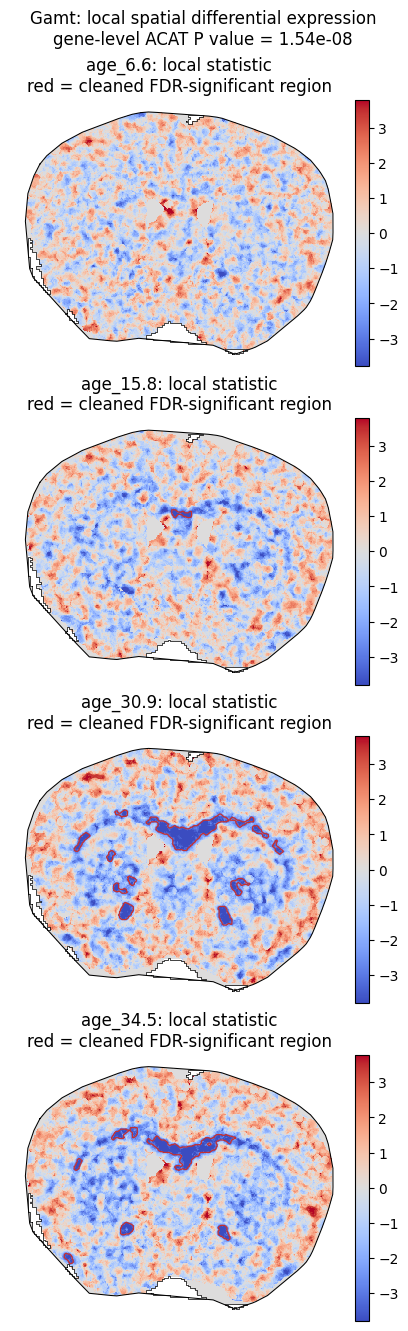

In [6]:
figure = plot_local_result(
    result,
    "Gamt",
    show_expression=False,
)